# 02 — Exploratory Data Analysis

**Project:** Telco Customer Churn Analysis

This notebook explores the cleaned dataset (`data/processed/telco_customer_churn_clean.csv`) to understand churn drivers, then reuses [`scripts/eda_report.py`](../scripts/eda_report.py) to regenerate the KPI summary and chart images used in the README and `reports/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "scripts"))

from eda_report import load_clean_data, compute_kpis

sns.set_theme(style="whitegrid")
df = load_clean_data()
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_flag,tenure_group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 mo
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 mo
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 mo
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 mo
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 mo


## 1. Dataset overview

In [2]:
print(df.shape)
df.describe(include="all").T

(7032, 23)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,7032,7032,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,7032,2,No,5890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
phone_service,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiple_lines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_security,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Overall churn rate

In [3]:
churn_rate = df["churn_flag"].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")
df["churn"].value_counts(normalize=True).mul(100).round(1)

Overall churn rate: 26.6%


churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64

## 3. Churn by contract type

Contract length is one of the strongest churn signals in telecom — month-to-month customers have no switching friction.

In [4]:
contract_churn = df.groupby("contract")["churn_flag"].mean().mul(100).sort_values(ascending=False)
contract_churn.round(1)

contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: churn_flag, dtype: float64

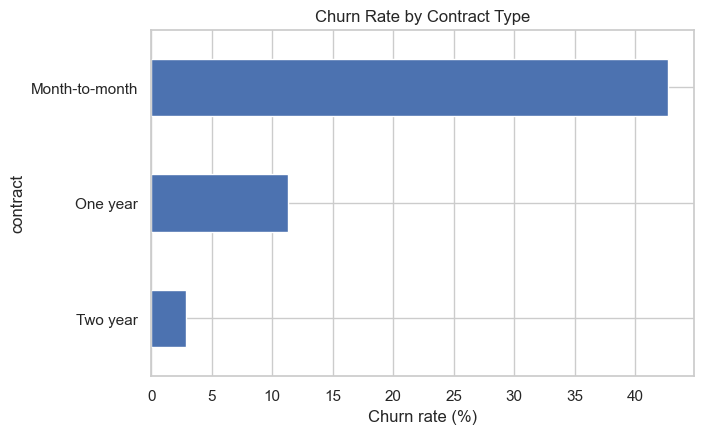

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
contract_churn.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_xlabel("Churn rate (%)")
ax.set_title("Churn Rate by Contract Type")
plt.show()

## 4. Churn by tenure

In [6]:
tenure_churn = df.groupby("tenure_group", observed=True)["churn_flag"].mean().mul(100)
tenure_churn.round(1)

tenure_group
0-12 mo     47.7
13-24 mo    28.7
25-48 mo    20.4
49-60 mo    14.4
61-72 mo     6.6
Name: churn_flag, dtype: float64

## 5. Churn by internet service and tech support

In [7]:
print("By internet service:")
print(df.groupby("internet_service")["churn_flag"].mean().mul(100).round(1))

print("\nBy tech support:")
print(df[df["tech_support"].isin(["Yes", "No"])].groupby("tech_support")["churn_flag"].mean().mul(100).round(1))

By internet service:
internet_service
DSL            19.0
Fiber optic    41.9
No              7.4
Name: churn_flag, dtype: float64

By tech support:
tech_support
No     41.6
Yes    15.2
Name: churn_flag, dtype: float64


## 6. Monthly charges vs churn

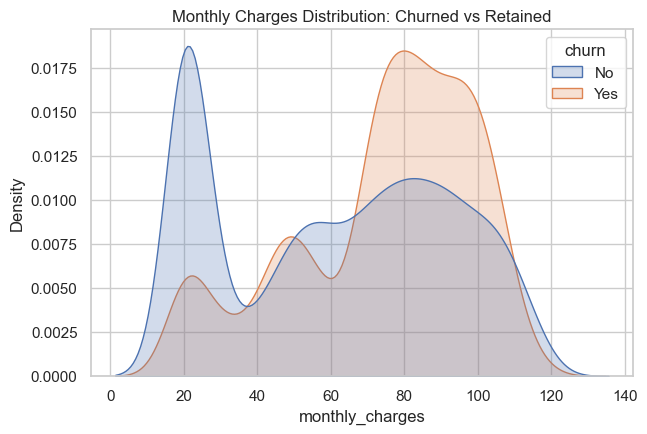

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(data=df, x="monthly_charges", hue="churn", fill=True, common_norm=False, ax=ax)
ax.set_title("Monthly Charges Distribution: Churned vs Retained")
plt.show()

## 7. KPI summary + regenerate report assets

Running the same KPI computation used by `scripts/eda_report.py` so the notebook numbers and the README numbers never drift apart.

In [9]:
kpis = compute_kpis(df)
kpis

{'total_customers': 7032,
 'overall_churn_rate_pct': np.float64(26.6),
 'avg_monthly_charges_usd': np.float64(64.8),
 'avg_tenure_months': np.float64(32.4),
 'month_to_month_churn_rate_pct': np.float64(42.7),
 'two_year_contract_churn_rate_pct': np.float64(2.8),
 'fiber_optic_churn_rate_pct': np.float64(41.9),
 'dsl_churn_rate_pct': np.float64(19.0),
 'no_tech_support_churn_rate_pct': np.float64(41.6),
 'with_tech_support_churn_rate_pct': np.float64(15.2)}

## 8. Key takeaways

- Month-to-month customers churn at roughly **15x** the rate of two-year contract customers.
- Churn risk is highest in a customer's **first 12 months** and drops sharply after that.
- **Fiber optic** internet customers churn more than **DSL** customers, despite fiber being the premium/higher-margin product.
- Customers **without Tech Support** churn at roughly **2.7x** the rate of customers with it.
- These four factors — contract type, tenure, internet service type, and tech support — are the primary churn drivers to act on (see README for recommendations).